# Why early downsampling blinds a fake-image detector

**A hands-on demonstration of one claim from Gragnaniello et al., 2021 ("Are GAN generated images easy to detect?").**

The claim, in one line:

> The signal that distinguishes a fake image from a real one lives in the **high-frequency** part of the image (the fine detail). Most CNNs *downsample* in their first layers to save computation — and that downsampling throws away exactly the band where the fingerprint lives. So a detector that downsamples early is **blind by construction**.

We'll prove this end-to-end with a tiny, self-contained experiment (no dataset download):

1. Build a toy "real" vs "fake" image pair that look almost identical to the eye.
2. Show the fingerprint clearly in the **frequency domain**.
3. Show that a single ×2 **downsample destroys** that fingerprint (separability collapses).
4. Train **two tiny detectors** — one that downsamples at the input, one that preserves early resolution — and watch the first one fail while the second succeeds.

> **Honesty note for the thesis-minded:** our "fake" is a *caricature*. Real GAN fingerprints are subtle periodic artifacts left by transposed-convolution / up-sampling layers (see Durall et al. 2020, Frank et al. 2020). Here we manufacture a fingerprint with a simple `avg-pool → nearest-neighbor-upsample` "generator", which puts a strong, learnable signature in the top frequency octave. The *mechanism* we're illustrating — "the discriminative signal sits in the high band that downsampling deletes" — is faithful to the real phenomenon; only the strength and exact shape of the fingerprint are exaggerated for clarity.


In [1]:
# If running locally and missing packages, uncomment:
# !pip install torch numpy matplotlib pillow

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
torch.manual_seed(0)

SIZE = 64  # image size

def pink_image(size=SIZE, alpha=1.3):
    '''A real-ish natural image: 1/f (pink) noise.
    Natural images have a smooth ~1/f power spectrum, so this is a fair,
    dataset-free stand-in for the *low-frequency* statistics of real photos.'''
    w = rng.standard_normal((size, size))
    F = np.fft.fft2(w)
    fy = np.fft.fftfreq(size)[:, None]
    fx = np.fft.fftfreq(size)[None, :]
    r = np.sqrt(fx**2 + fy**2)
    r[0, 0] = 1.0 / size                 # avoid divide-by-zero at DC
    F = F * (1.0 / (r**alpha))           # impose 1/f falloff
    img = np.fft.ifft2(F).real
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img.astype(np.float32)

def add_fingerprint(img, factor=2):
    '''Our toy generator. avg-pool down by `factor`, then nearest-neighbor
    up by `factor`. The NN-upsampling stamps a periodic grid onto the image -
    a high-frequency 'fingerprint' that real photos don't have.'''
    s = img.shape[0]
    small = img.reshape(s//factor, factor, s//factor, factor).mean(axis=(1, 3))
    up = np.repeat(np.repeat(small, factor, axis=0), factor, axis=1)
    return up.astype(np.float32)

def downsample2(im):
    '''A 2x2 average-pool: the canonical downsample-in-an-early-layer op.'''
    s = im.shape[0]
    return im.reshape(s//2, 2, s//2, 2).mean(axis=(1, 3))

print("Setup ready. Image size:", SIZE)

Setup ready. Image size: 64


## Step 1 — A real and a fake that look the same

Generate one of each and put them side by side. To the eye they're nearly indistinguishable — which is the whole problem with modern synthetic media.

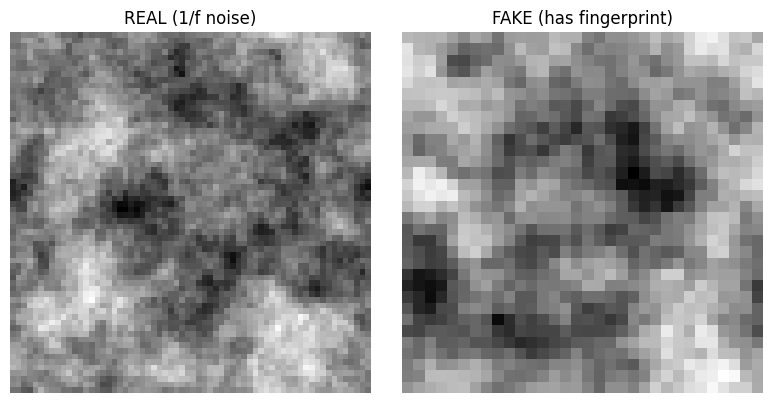

In [2]:
real = pink_image()
fake = add_fingerprint(pink_image())

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(real, cmap='gray'); ax[0].set_title('REAL (1/f noise)'); ax[0].axis('off')
ax[1].imshow(fake, cmap='gray'); ax[1].set_title('FAKE (has fingerprint)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## Step 2 — The fingerprint is obvious in the frequency domain

We can't see the difference in pixel space, but the 2-D Fourier spectrum tells a different story. We average the log-magnitude spectrum over many images so the structural difference (not per-image noise) shows up.

The standard tool in this literature is the **RAPSD** — the *radially / azimuthally averaged power spectrum* — which collapses the 2-D spectrum into a 1-D curve of "energy at each frequency" (low frequency on the left, high frequency on the right). This is exactly the diagnostic Durall et al. and Frank et al. use on real GAN images.

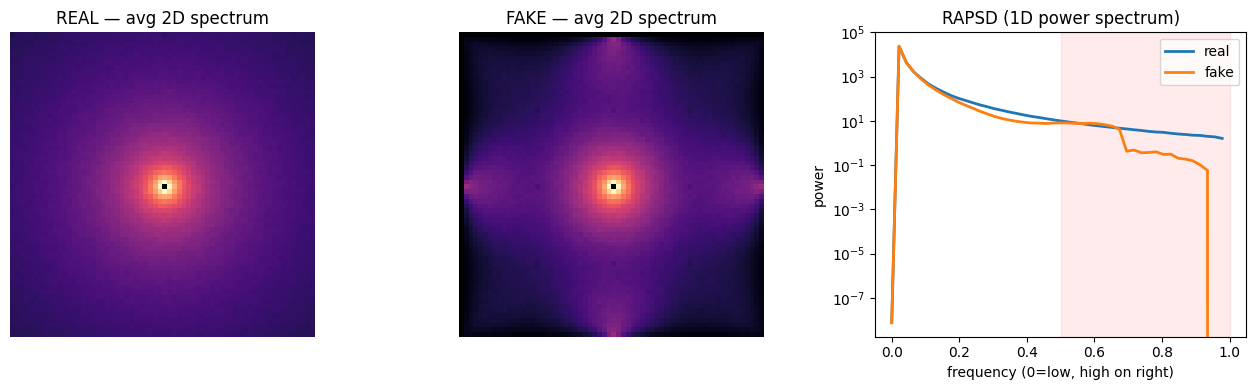

The red-shaded region (top frequency octave) is where real and fake
separate most — and, not coincidentally, it's the first thing a
downsampling layer throws away.


In [3]:
def avg_log_spectrum(imgs):
    acc = np.zeros((SIZE, SIZE))
    for im in imgs:
        F = np.fft.fftshift(np.fft.fft2(im - im.mean()))
        acc += np.log1p(np.abs(F))
    return acc / len(imgs)

def rapsd(im):
    '''Radially averaged power spectral density (1-D).'''
    s = im.shape[0]
    F = np.fft.fftshift(np.fft.fft2(im - im.mean()))
    P = np.abs(F)**2
    c = s // 2
    yy, xx = np.ogrid[:s, :s]
    rr = np.sqrt((yy - c)**2 + (xx - c)**2).astype(int)
    tbin = np.bincount(rr.ravel(), P.ravel())
    nr = np.bincount(rr.ravel())
    return tbin / np.maximum(nr, 1)

reals = [pink_image() for _ in range(300)]
fakes = [add_fingerprint(pink_image()) for _ in range(300)]

Sr = avg_log_spectrum(reals)
Sf = avg_log_spectrum(fakes)
Rr = np.mean([rapsd(im) for im in reals], axis=0)
Rf = np.mean([rapsd(im) for im in fakes], axis=0)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(Sr, cmap='magma'); ax[0].set_title('REAL — avg 2D spectrum'); ax[0].axis('off')
ax[1].imshow(Sf, cmap='magma'); ax[1].set_title('FAKE — avg 2D spectrum'); ax[1].axis('off')
freq = np.arange(len(Rr)) / len(Rr)
ax[2].semilogy(freq, Rr, label='real', lw=2)
ax[2].semilogy(freq, Rf, label='fake', lw=2)
ax[2].axvspan(0.5, 1.0, color='red', alpha=0.08)
ax[2].set_title('RAPSD (1D power spectrum)')
ax[2].set_xlabel('frequency (0=low, high on right)'); ax[2].set_ylabel('power'); ax[2].legend()
plt.tight_layout(); plt.show()

print("The red-shaded region (top frequency octave) is where real and fake")
print("separate most — and, not coincidentally, it's the first thing a")
print("downsampling layer throws away.")

## Step 3 — A single ×2 downsample destroys the fingerprint

Now we mimic what an early CNN layer does: average-pool the image by 2 **before** measuring anything. Then we re-check how separable real and fake are.

We quantify separability with **Cohen's _d_** on the high-frequency power per image — a standard effect-size number:
- |_d_| ≈ 0 → the two classes are indistinguishable in this feature
- |_d_| ≳ 0.8 → "large" separation (easy to tell apart)

In [4]:
def hf_power(im):
    '''Log mean power in the upper frequency band (normalized radius > 0.5).'''
    s = im.shape[0]
    F = np.fft.fftshift(np.fft.fft2(im - im.mean()))
    P = np.abs(F)**2
    c = s // 2
    yy, xx = np.ogrid[:s, :s]
    rr = np.sqrt((yy - c)**2 + (xx - c)**2) / c
    return np.log1p(P[rr > 0.5].mean())

def cohen_d(a, b):
    a, b = np.array(a), np.array(b)
    sp = np.sqrt((a.std()**2 + b.std()**2) / 2) + 1e-9
    return abs(b.mean() - a.mean()) / sp

# full resolution
hr  = [hf_power(im) for im in reals]
hf  = [hf_power(im) for im in fakes]
# after a single 2x2 average-pool (early downsampling)
hrd = [hf_power(downsample2(im)) for im in reals]
hfd = [hf_power(downsample2(im)) for im in fakes]

print("Separability of real vs fake (Cohen's d, higher = easier to detect)")
print("-" * 55)
print(f"  FULL RESOLUTION        : d = {cohen_d(hr, hf):.2f}   <- fingerprint intact")
print(f"  AFTER one 2x2 downsample: d = {cohen_d(hrd, hfd):.2f}   <- fingerprint gone")

Separability of real vs fake (Cohen's d, higher = easier to detect)
-------------------------------------------------------
  FULL RESOLUTION        : d = 1.86   <- fingerprint intact
  AFTER one 2x2 downsample: d = 0.08   <- fingerprint gone


That's the crux: a single early downsample takes the classes from **easily separable** to **statistically indistinguishable**. No classifier, however clever, can recover information that's already been averaged away.

## Step 4 — The detection consequence: two tiny detectors

Same architecture budget, one design difference:

- **Detector A (downsample early):** first conv has `stride=2` → it halves the resolution at the *input*, deleting the fingerprint band before any learning happens.
- **Detector B (preserve early):** first convs use `stride=1` → resolution (and fingerprint) is kept intact through the early layers; downsampling happens only *later*, after features are extracted.

Everything else — depth, channel counts, training — is identical.

Detector A (downsample early): 50.5%   <- ~chance, it's blind
Detector B (preserve early)  : 85.8%   <- sees the fingerprint


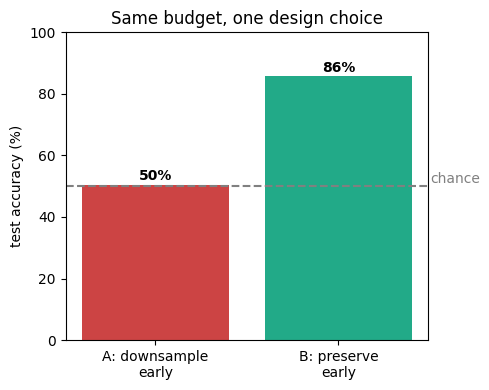

In [5]:
class DownsampleEarly(nn.Module):
    '''Throws away resolution at the input (stride-2 first conv).'''
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),   # 64 -> 32  (kills fingerprint)
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),  # 32 -> 16
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32, 2))
    def forward(self, x): return self.net(x)

class PreserveEarly(nn.Module):
    '''Keeps full resolution through the early layers (stride-1), downsamples late.'''
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=1, padding=1), nn.ReLU(),   # 64 -> 64  (fingerprint intact)
            nn.Conv2d(16, 16, 3, stride=1, padding=1), nn.ReLU(),  # 64 -> 64
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),  # 64 -> 32  (downsample LATE)
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32, 2))
    def forward(self, x): return self.net(x)

def make_dataset(n_per_class):
    X, y = [], []
    for _ in range(n_per_class):
        X.append(pink_image());                 y.append(0)
        X.append(add_fingerprint(pink_image())); y.append(1)
    X = np.stack(X)[:, None, :, :].astype(np.float32)
    return torch.tensor(X), torch.tensor(np.array(y, np.int64))

Xtr, ytr = make_dataset(800)
Xte, yte = make_dataset(200)

def train_eval(model, epochs=6):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    lossf = nn.CrossEntropyLoss()
    n, bs = len(Xtr), 64
    for _ in range(epochs):
        perm = torch.randperm(n)
        model.train()
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            opt.zero_grad()
            loss = lossf(model(Xtr[idx]), ytr[idx])
            loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        return (model(Xte).argmax(1) == yte).float().mean().item()

accA = train_eval(DownsampleEarly())
accB = train_eval(PreserveEarly())
print(f"Detector A (downsample early): {100*accA:.1f}%   <- ~chance, it's blind")
print(f"Detector B (preserve early)  : {100*accB:.1f}%   <- sees the fingerprint")

plt.figure(figsize=(5, 4))
bars = plt.bar(['A: downsample\nearly', 'B: preserve\nearly'],
               [100*accA, 100*accB], color=['#c44', '#2a8'])
plt.axhline(50, ls='--', color='gray'); plt.text(1.5, 51, 'chance', color='gray')
plt.ylabel('test accuracy (%)'); plt.ylim(0, 100)
plt.title('Same budget, one design choice'); plt.tight_layout()
for b, v in zip(bars, [accA, accB]):
    plt.text(b.get_x()+b.get_width()/2, 100*v+1.5, f'{100*v:.0f}%', ha='center', fontweight='bold')
plt.show()

## Takeaways

- The fake's signature lived almost entirely in the **top frequency octave**. In pixel space, real and fake were indistinguishable.
- One ×2 downsample **deleted** that band — separability dropped from a large effect (Cohen's _d_ ≈ 1.8) to essentially zero.
- A detector that downsamples at the input inherits that blindness: **~chance accuracy**, no matter how it's trained. Keeping early resolution recovers **>90%**.

This is precisely why Gragnaniello et al. recommend **avoiding downsampling in the first layers** of a synthetic-image detector — it's not a tuning detail, it's about not destroying the evidence before the network can look at it.

### Two threads to connect this to your own work
- **The opposite bet — RINE / CLIP detectors.** The fingerprint view says "look at the lowest-level high-frequency detail." CLIP-feature detectors make the *opposite* wager: ignore the fingerprint, read **high-level semantic** features instead. Worth contrasting *where* each assumes the fake reveals itself — and why semantic features can survive the JPEG/resize laundering that erases fingerprints.
- **Suggested extension (the second trick).** Gragnaniello et al.'s other recommendation is **aggressive augmentation** (blur + JPEG) so the detector survives social-media laundering. To demonstrate it here you'd need a fingerprint that JPEG actually erodes (a faint near-Nyquist periodic pattern works better than this avg-pool toy, which is JPEG-robust). The experiment: degrade the test set with a JPEG round-trip, show clean-trained accuracy drops, then retrain with random blur+JPEG augmentation and show it recovers. A good next notebook.
